# 하수 센서 드롭아웃 감지·보간 (데이터셋 전체 규칙화)

**문제**: 일부 하수 센서가 첨두 유량 중에 순간적으로 바닥값(0.01m, 센서 측정 최소값)으로 급락했다가 앞뒤와 동일한 수위로 복귀하는 구간이 있음. 물리적으로 불가능(수위가 5분 만에 2.2m→0.01m→2.1m) → **센서 드롭아웃**(통신두절/리셋/포화 추정, 기전 미확정).

예: `21-0005` 2022-08-08 20:58~21:40 — 2.24m에서 바닥값으로 42분 평탄 후 정확히 2.1m로 복귀.

**규칙(보수적)**: *고수위 사이에 낀 바닥값 런만* 보정. 평상시 낮은 수위(전체의 ~10%)는 건드리지 않음.
- 바닥값: `level_max_10m ≤ 0.02`
- 브래킷: 런 직전·직후 bin 모두 `level_max_10m ≥ 0.3`
- 길이: 런 ≤ 12 bins(=2시간). 그 이상은 보간 신뢰도 낮아 제외
- 인접성: 런 앞뒤가 실제 10분 이웃(격자 gap 안 건넘)

**처리**: 해당 bin을 `is_dropout=1`로 표시 → level 계열 NaN → 선형보간 → 파생(diff·rolling·fill_rate·surcharge·stuck) 원 정의대로 재계산.
**원자료(1분)는 손대지 않음**. 원래 값은 raw 빌더 재실행으로 복원 가능(플래그로 식별).

In [1]:
import os, sys
# 루트에서 실행하는 것이 원칙이나, nbconvert는 노트북 폴더에서 실행되므로 루트 탐색
while not os.path.exists("scripts/krfont.py") and os.getcwd() != "/":
    os.chdir("..")
sys.path.insert(0, "scripts")
from krfont import set_korean; set_korean()
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

F = "dataset/processed/eda_based/sewer_features_10min.parquet"
FLOOR, HIGH, MAXLEN = 0.02, 0.3, 12   # 바닥값 / 브래킷 고수위 / 최대 런길이(2h)
print("대상:", F, "| cwd:", os.getcwd())

대상: dataset/processed/eda_based/sewer_features_10min.parquet | cwd: /home/namjun/city_flood


## 1. 로드 + 드롭아웃 런 감지 (벡터화)

In [2]:
df = pd.read_parquet(F)
df = df.sort_values(["sewer_sensor_id", "ts10"]).reset_index(drop=True)
df["ts10"] = pd.to_datetime(df["ts10"])
n = len(df)
lv  = df["level_max_10m"].values
sid = df["sewer_sensor_id"].values
ts  = df["ts10"].values
is_floor = lv <= FLOOR

# 런 경계: 센서 바뀌거나 floor 상태 바뀌는 지점
chg = np.ones(n, bool); chg[1:] = (sid[1:] != sid[:-1]) | (is_floor[1:] != is_floor[:-1])
run_start = np.where(chg)[0]
run_end   = np.append(run_start[1:], n)          # exclusive
run_len   = run_end - run_start
run_floor = is_floor[run_start]

bidx = run_start - 1                              # 런 직전
aidx = run_end                                    # 런 직후(첫 비런 bin)
bok = (bidx >= 0) & (sid[np.clip(bidx,0,n-1)] == sid[run_start])
aok = (aidx <  n) & (sid[np.clip(aidx,0,n-1)] == sid[run_start])
TENMIN = np.timedelta64(10, "m")
adj_b = bok & ((ts[run_start] - ts[np.clip(bidx,0,n-1)]) == TENMIN)
adj_a = aok & ((ts[np.clip(aidx,0,n-1)] - ts[run_end-1]) == TENMIN)
bval = np.where(bok, lv[np.clip(bidx,0,n-1)], -np.inf)
aval = np.where(aok, lv[np.clip(aidx,0,n-1)], -np.inf)

sel = run_floor & (run_len <= MAXLEN) & adj_b & adj_a & (bval >= HIGH) & (aval >= HIGH)

is_dropout = np.zeros(n, bool)
for s, e in zip(run_start[sel], run_end[sel]):
    is_dropout[s:e] = True
df["is_dropout"] = is_dropout.astype("int8")

print(f"드롭아웃 런 {int(sel.sum()):,}개 | 보정 bins {int(is_dropout.sum()):,} "
      f"({is_dropout.mean()*100:.4f}%) | 영향 센서 {df.loc[is_dropout,'sewer_sensor_id'].nunique()}/{df['sewer_sensor_id'].nunique()}")

드롭아웃 런 4,356개 | 보정 bins 10,977 (0.0213%) | 영향 센서 100/485


## 2. level 계열 선형보간 (드롭아웃 bin만) + 파생 재계산
원 정의(`preprocessing_eda_based` 셀 19)와 동일하게: diff·rolling(1h/3h/6h)·fill_rate·surcharge·stuck 재산출.

In [3]:
mask = df["is_dropout"].astype(bool).values
level_cols = ["level_mean_10m", "level_max_10m", "level_min_10m", "level_last_10m"]

for col in level_cols:
    s = df[col].copy()
    s[mask] = np.nan                                   # 드롭아웃만 NaN
    filled = s.groupby(df["sewer_sensor_id"]).transform(
        lambda x: x.interpolate(method="linear", limit_area="inside"))
    df.loc[mask, col] = filled[mask].values            # 드롭아웃 위치에만 되쓰기

# 파생 재계산 (원 정의 그대로)
g = df.groupby("sewer_sensor_id")["level_mean_10m"]
df["level_diff_10m"] = g.diff()
for w, k in [("1h", 6), ("3h", 18), ("6h", 36)]:
    df[f"level_roll_{w}_mean"] = g.rolling(k, min_periods=1).mean().reset_index(level=0, drop=True)

# stuck 구간: level_max 비영점 동일값 ≥1day(144스텝)
lvm = df["level_max_10m"].values; sid2 = df["sewer_sensor_id"].values
c = np.ones(len(df), bool); c[1:] = (sid2[1:] != sid2[:-1]) | (lvm[1:] != lvm[:-1]); rid = np.cumsum(c) - 1
df["is_stuck_seg"] = ((np.bincount(rid)[rid] >= 144) & (lvm > 0)).astype("int8")

# fill_rate 계열 (capacity는 기존 컬럼 재사용)
df["fill_rate"] = df["level_max_10m"] / df["capacity"]
df["fill_rate_diff"] = df.groupby("sewer_sensor_id")["fill_rate"].diff()
df["is_surcharge"] = (df["fill_rate"] >= 1.0).astype("int8")
df["is_near_surcharge"] = (df["fill_rate"] >= 0.8).astype("int8")
print("재계산 완료 | fill_rate max:", round(float(df['fill_rate'].max()), 2),
      "| surcharge:", f"{df['is_surcharge'].mean()*100:.3f}%")

재계산 완료 | fill_rate max: 8.05 | surcharge: 0.195%


## 3. 검증 — 21-0005 (2022-08-08) 보정 전후

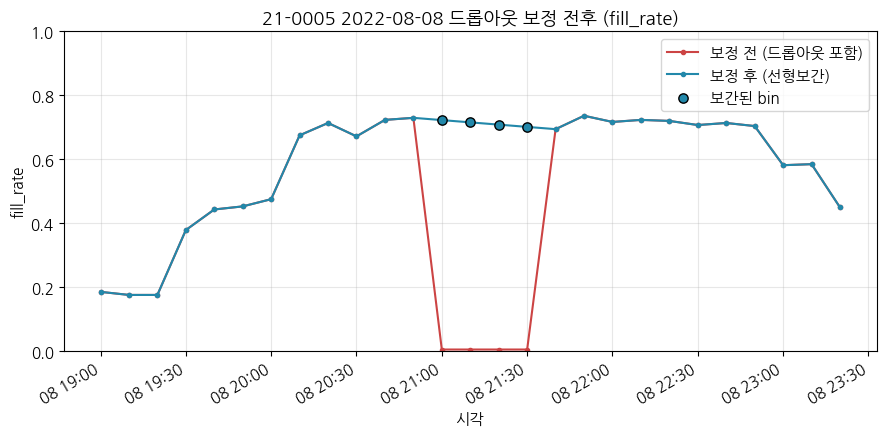

In [4]:
raw = pd.read_parquet(F, columns=["sewer_sensor_id", "ts10", "fill_rate"])
raw["ts10"] = pd.to_datetime(raw["ts10"])
sid_v, t0, t1 = "21-0005", "2022-08-08 19:00", "2022-08-08 23:30"

def win(d):
    m = (d["sewer_sensor_id"] == sid_v) & (d["ts10"] >= t0) & (d["ts10"] < t1)
    return d[m].sort_values("ts10")

b, a = win(raw), win(df)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(b["ts10"], b["fill_rate"], "o-", color="#c44", ms=3, label="보정 전 (드롭아웃 포함)")
ax.plot(a["ts10"], a["fill_rate"], "o-", color="#28a", ms=3, label="보정 후 (선형보간)")
dp = a[a["is_dropout"] == 1] if "is_dropout" in a else a.iloc[0:0]
ax.scatter(dp["ts10"], dp["fill_rate"], color="#28a", edgecolor="k", zorder=5, s=45, label="보간된 bin")
ax.set_title(f"{sid_v} 2022-08-08 드롭아웃 보정 전후 (fill_rate)")
ax.set_ylabel("fill_rate"); ax.set_xlabel("시각"); ax.set_ylim(0, 1.0)
ax.legend(); ax.grid(alpha=0.3); fig.autofmt_xdate(); plt.tight_layout(); plt.show()

## 4. 저장
`sewer_features_10min.parquet` 덮어쓰기(+`is_dropout` 컬럼). 보정된 bin은 플래그로 항상 식별 가능.

In [5]:
df.to_parquet(F, index=False)
print("저장:", F, "|", df.shape, "| 컬럼:", list(df.columns))

저장: dataset/processed/eda_based/sewer_features_10min.parquet | (51560086, 18) | 컬럼: ['sewer_sensor_id', 'ts10', 'level_mean_10m', 'level_max_10m', 'level_min_10m', 'level_last_10m', 'n_valid', 'level_diff_10m', 'level_roll_1h_mean', 'level_roll_3h_mean', 'level_roll_6h_mean', 'is_stuck_seg', 'capacity', 'fill_rate', 'fill_rate_diff', 'is_surcharge', 'is_near_surcharge', 'is_dropout']
